In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
class SubState(TypedDict):
    input_text: str
    translated_text: str

In [4]:
subgraph_llm = ChatGroq(model="openai/gpt-oss-120b")

In [5]:
def translate_text(state: SubState):
    prompt = f"""Translate the following text to Hindi.
    Keep it natural and clear. Do not add extra content.
    Text:
    {state["input_text"]}
    """.strip()
    translated_text = subgraph_llm.invoke(prompt).content
    return {'translated_text': translated_text}

In [6]:
subgraph_builder = StateGraph(SubState)
subgraph_builder.add_node("translate_text",translate_text)

subgraph_builder.add_edge(START, "translate_text")
subgraph_builder.add_edge("translate_text", END)

subgraph = subgraph_builder.compile()

In [7]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_hin: str

In [8]:
parent_llm = ChatGroq(model="openai/gpt-oss-120b")

In [9]:
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(f"You are helpful assistant. Answer clearly. \n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [10]:
def translate_answer(state: ParentState):
    result = subgraph.invoke({'input_text': state['answer_eng']})
    return {'answer_hin': result["translated_text"]}

In [11]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate",translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate',END)

graph = parent_builder.compile()


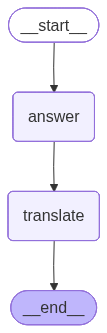

In [12]:
graph

In [13]:
graph.invoke({'question':'what is quantum Physics'})

{'question': 'what is quantum Physics',
 'answer_eng': '**Quantum physics (or quantum mechanics) is the branch of physics that describes how nature behaves at the smallest scales—atoms, molecules, sub‑atomic particles, and even fields that permeate space.**  \n\nBelow is a compact, step‑by‑step overview that captures the essence of the theory, its core ideas, and why it matters.\n\n---\n\n## 1. Why “quantum”?\n- **Quantization:** Certain physical quantities (energy, angular momentum, electric charge) can only take discrete values—*quanta*—rather than a continuous range.  \n- **Planck’s constant (ℏ ≈ 1.054\u202f×\u202f10⁻³⁴\u202fJ·s)** sets the scale at which quantum effects become noticeable. When actions are comparable to ℏ, classical (Newtonian) physics fails.\n\n---\n\n## 2. Foundational Principles\n\n| Principle | What it says | Typical consequence |\n|-----------|--------------|----------------------|\n| **Wave‑particle duality** | Particles (electrons, photons, etc.) exhibit both